<a href="https://colab.research.google.com/github/HoangAncient/MagicPost/blob/main/M4_Clustering_Mall_KMeans_HaDT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab P11 – Phân khúc khách hàng trung tâm thương mại với K-Means

**Module M4 – C7: K-Means & Hierarchical Clustering**  
**Machine Learning ứng dụng | Học viện Viettel | Tháng 6/2026**  
**Giảng viên: Thanh-Ha DO**

---

## Mục tiêu bài lab

Sau khi hoàn thành lab này, học viên có thể:

- Mô tả bài toán phân khúc khách hàng dưới góc độ học không giám sát
- Tiền xử lý dữ liệu cho bài toán phân cụm (chuẩn hóa đúng cách)
- Xây dựng và huấn luyện mô hình K-Means với `scikit-learn`
- Tối ưu mô hình bằng Elbow Method và K-Means++
- Đánh giá chất lượng phân cụm bằng Silhouette Coefficient
- Thực hiện Hierarchical Clustering và vẽ Dendrogram
- Chọn số cụm K và diễn giải kết quả kinh doanh

---

## Mô tả bài toán

**Dữ liệu:** Mall Customers Dataset – thông tin khách hàng của một trung tâm thương mại  
bao gồm độ tuổi, giới tính, thu nhập hàng năm và điểm chi tiêu (Spending Score 1–100).

**Bài toán:** Phân chia khách hàng thành các nhóm có đặc điểm tương đồng để:
- Xây dựng chiến lược marketing phù hợp từng nhóm
- Tối ưu hóa trải nghiệm mua sắm
- Cá nhân hóa dịch vụ và ưu đãi

> **Đây là bài toán học không giám sát**: không có nhãn $y$ sẵn có –  
> thuật toán tự khám phá cấu trúc tiềm ẩn trong dữ liệu.

## 0. Import thư viện

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print('Import thành công!')

Import thành công!


## 1. Tải và khám phá dữ liệu

Dữ liệu Mall Customers với 5 phân khúc khách hàng rõ ràng.
Khi có file thực tế, thay bằng: `df = pd.read_csv('Mall_Customers.csv')`

In [ ]:
# Tạo dữ liệu mô phỏng Mall Customers – 5 phân khúc
np.random.seed(2024)
seg_params = [
    (0.6, 28, 5, 80, 10, 82, 8,  40),  # A: Trẻ, thu nhập cao, chi tiêu cao
    (0.5, 47, 8, 78, 10, 18, 8,  40),  # B: Trung niên, thu nhập cao, tiết kiệm
    (0.55,38, 9, 42, 10, 52, 12, 50),  # C: Thu nhập TB, chi tiêu TB
    (0.7, 24, 4, 18,  6, 80, 8,  40),  # D: Trẻ, thu nhập thấp, chi tiêu cao
    (0.4, 52,10, 18,  6, 18, 7,  30),  # E: Lớn tuổi, thu nhập thấp, tiết kiệm
]
rows = []
for fr, am, as_, im, is_, sm, ss, ns in seg_params:
    genders = np.random.choice(['Female','Male'], size=ns, p=[fr, 1-fr])
    ages    = np.random.normal(am, as_, ns).clip(18, 70).astype(int)
    incomes = np.random.normal(im, is_, ns).clip(10, 120).round(1)
    scores  = np.random.normal(sm, ss, ns).clip(1, 100).astype(int)
    for g, a, inc, sc in zip(genders, ages, incomes, scores):
        rows.append({'Gender': g, 'Age': a, 'Annual_Income_k': inc, 'Spending_Score': sc})

df = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)
df.index.name = 'CustomerID'
print('Shape:', df.shape)
df.head(10)

Shape: (200, 4)


,Gender,Age,Annual_Income_k,Spending_Score
CustomerID,,,,
0,Male,53,40.6,33
1,Male,22,85.9,79
2,Female,30,63.9,74
3,Female,27,15.2,79
4,Male,47,38.7,52
5,Female,41,46.2,36
6,Female,54,81.2,14
7,Male,37,21.1,25
8,Female,65,11.8,14


In [ ]:
print('Kiểm tra missing values:')
print(df.isnull().sum())
print()
df.describe().round(2)

Kiểm tra missing values:
Gender             0
Age                0
Annual_Income_k    0
Spending_Score     0
dtype: int64



,Age,Annual_Income_k,Spending_Score
count,200.00,200.00,200.00
mean,37.01,48.27,50.81
std,12.16,27.63,29.45
min,18.00,10.00,1.00
25%,27.00,21.45,19.00
50%,35.50,45.50,53.00
75%,45.25,73.65,78.00
max,65.00,104.00,100.00


### 1.1. Phân phối dữ liệu

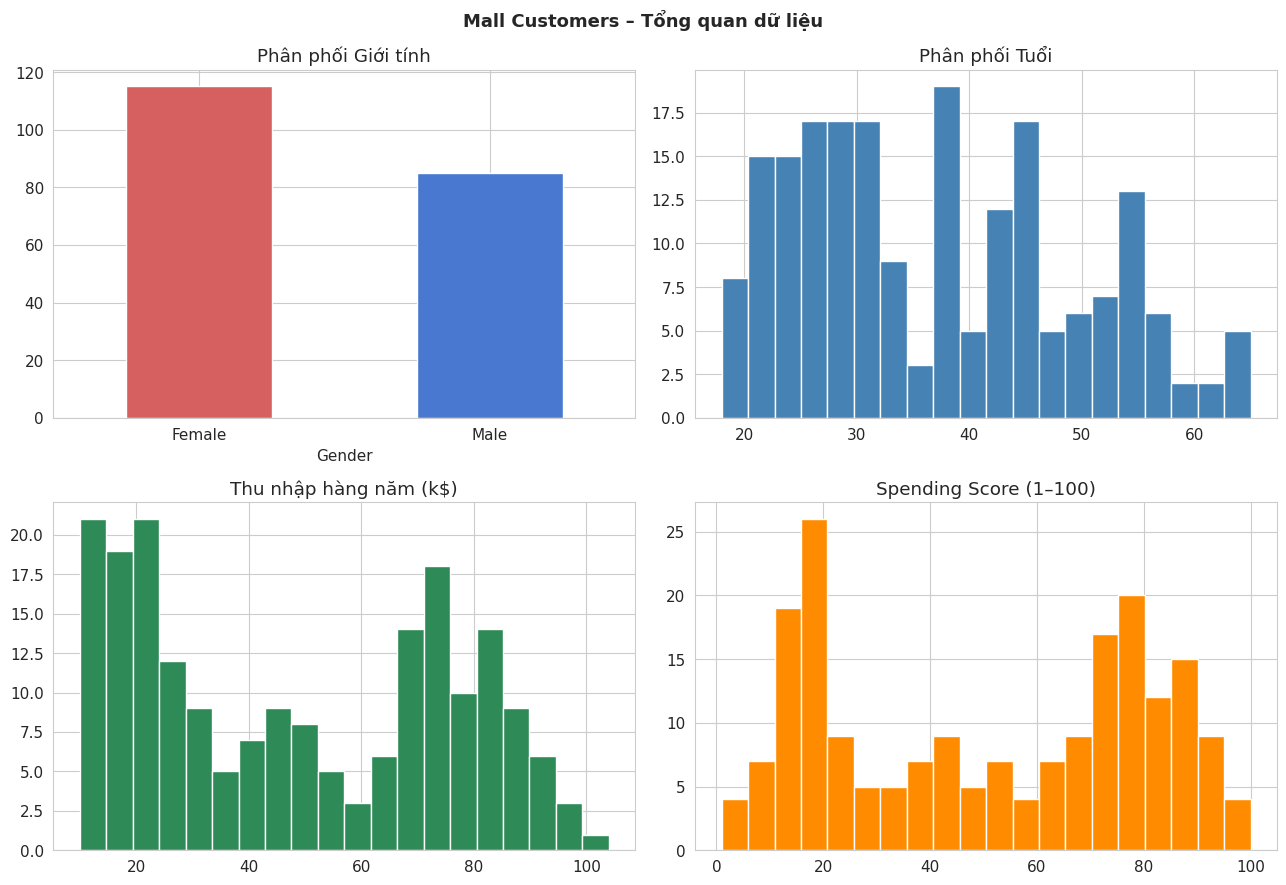

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

# Giới tính
df['Gender'].value_counts().plot(kind='bar', ax=axes[0,0],
    color=['#D65F5F','#4878CF'], edgecolor='white')
axes[0,0].set_title('Phân phối Giới tính')
axes[0,0].tick_params(axis='x', rotation=0)

# Tuổi
axes[0,1].hist(df['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0,1].set_title('Phân phối Tuổi')

# Thu nhập
axes[1,0].hist(df['Annual_Income_k'], bins=20, color='seagreen', edgecolor='white')
axes[1,0].set_title('Thu nhập hàng năm (k$)')

# Spending Score
axes[1,1].hist(df['Spending_Score'], bins=20, color='darkorange', edgecolor='white')
axes[1,1].set_title('Spending Score (1–100)')

plt.suptitle('Mall Customers – Tổng quan dữ liệu', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

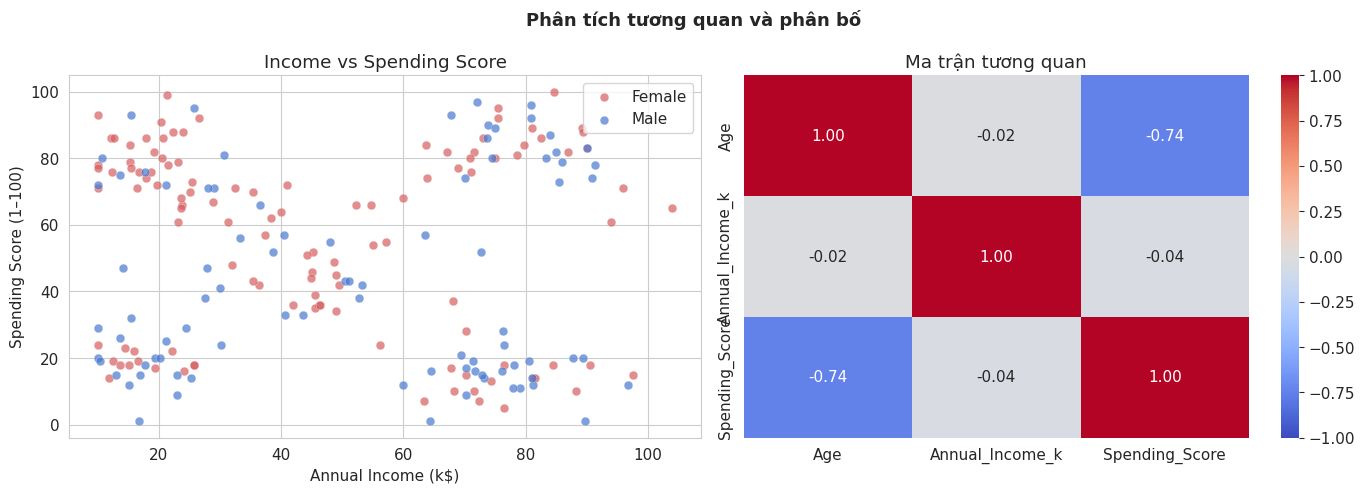

In [ ]:
# Scatter plot: Annual Income vs Spending Score (phân biệt giới tính)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
color_map = {'Female': '#D65F5F', 'Male': '#4878CF'}

for gender, grp in df.groupby('Gender'):
    axes[0].scatter(grp['Annual_Income_k'], grp['Spending_Score'],
                    c=color_map[gender], alpha=0.7, s=40,
                    label=gender, edgecolors='white', linewidths=0.3)
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1–100)')
axes[0].set_title('Income vs Spending Score')
axes[0].legend()

# Correlation heatmap
num_cols = ['Age', 'Annual_Income_k', 'Spending_Score']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Ma trận tương quan')

plt.suptitle('Phân tích tương quan và phân bố', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Tiền xử lý dữ liệu

In [ ]:
# Chọn features phân cụm: thu nhập và điểm chi tiêu
FEATURES = ['Annual_Income_k', 'Spending_Score']
X_raw = df[FEATURES].values

# Chuẩn hóa – quan trọng vì K-means dùng khoảng cách Euclidean
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print('Kích thước dữ liệu:', X.shape)
for i, col in enumerate(FEATURES):
    print(f'{col}: trước = (mean={X_raw[:,i].mean():.1f}, std={X_raw[:,i].std():.1f})'
          f'  →  sau = (mean={X[:,i].mean():.3f}, std={X[:,i].std():.3f})')

Kích thước dữ liệu: (200, 2)
Annual_Income_k: trước = (mean=48.3, std=27.6)  →  sau = (mean=0.000, std=1.000)
Spending_Score: trước = (mean=50.8, std=29.4)  →  sau = (mean=-0.000, std=1.000)


## 3. Chọn số cụm K

### 3.1. Elbow Method

Thuật toán K-means tối thiểu hóa:
$$\mathcal{L} = \sum_{k=1}^{K}\sum_{\mathbf{x}_i \in C_k}\|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2$$

Vẽ SSE theo $K$, tìm điểm khuỷu tay.

SSE theo K:
  K= 1: SSE=400.00
  K= 2: SSE=233.19
  K= 3: SSE=130.19
  K= 4: SSE=61.57
  K= 5: SSE=34.98
  K= 6: SSE=30.15
  K= 7: SSE=26.35
  K= 8: SSE=23.51
  K= 9: SSE=19.91
  K=10: SSE=18.22

Elbow gợi ý: K=2


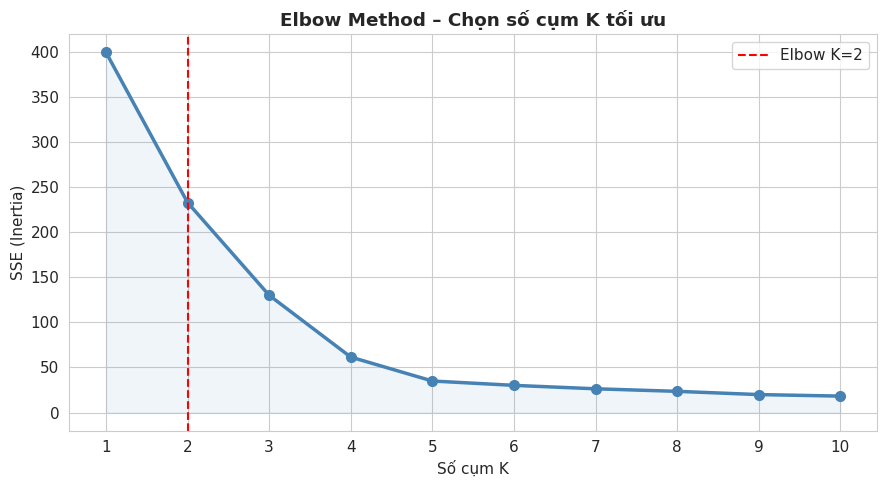

In [ ]:
sse_list = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X)
    sse_list.append(km.inertia_)

# Tính elbow bằng curvature
sse_diff2 = np.diff(np.diff(sse_list))
elbow_k = np.argmax(sse_diff2) + 2

print('SSE theo K:')
for k, s in zip(K_range, sse_list):
    print(f'  K={k:2d}: SSE={s:.2f}')
print(f'\nElbow gợi ý: K={elbow_k}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_range), sse_list, 'o-', color='steelblue', lw=2.5, ms=7)
ax.axvline(elbow_k, color='red', linestyle='--', lw=1.5, label=f'Elbow K={elbow_k}')
ax.fill_between(list(K_range), sse_list, alpha=0.08, color='steelblue')
ax.set_xlabel('Số cụm K')
ax.set_ylabel('SSE (Inertia)')
ax.set_title('Elbow Method – Chọn số cụm K tối ưu', fontweight='bold')
ax.legend()
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.show()

### 3.2. Silhouette Score

Silhouette score $s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))} \in [-1, 1]$

- $a(i)$: khoảng cách trung bình nội cụm (cohesion)
- $b(i)$: khoảng cách trung bình đến cụm gần nhất (separation)
- Giá trị gần 1 = phân cụm tốt

Silhouette score theo K:
  K=2: 0.4025
  K=3: 0.5078
  K=4: 0.5873
  K=5: 0.6184 ← TỐT NHẤT
  K=6: 0.5674
  K=7: 0.5122
  K=8: 0.4515
  K=9: 0.4566
  K=10: 0.4380


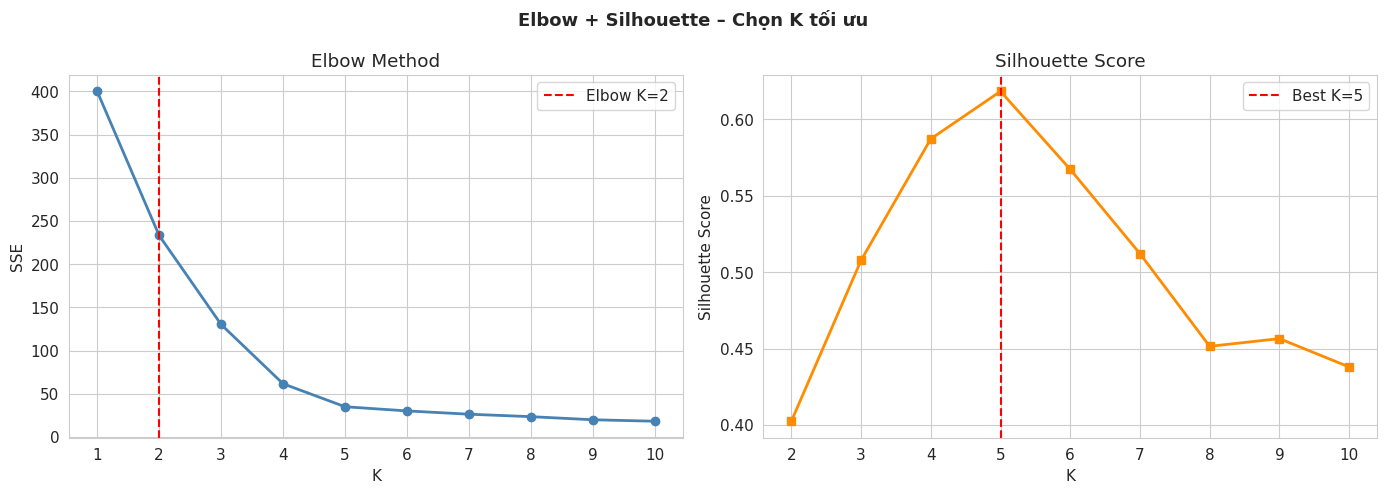


Kết luận: chọn K = 5


In [ ]:
sil_list = []
K_range2 = range(2, 11)

for k in K_range2:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)
    sil_list.append(silhouette_score(X, labels))

best_k_sil = list(K_range2)[np.argmax(sil_list)]

print('Silhouette score theo K:')
for k, s in zip(K_range2, sil_list):
    mark = ' ← TỐT NHẤT' if k == best_k_sil else ''
    print(f'  K={k}: {s:.4f}{mark}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), sse_list, 'o-', color='steelblue', lw=2)
axes[0].axvline(elbow_k, color='red', linestyle='--', label=f'Elbow K={elbow_k}')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K'); axes[0].set_ylabel('SSE')
axes[0].legend(); axes[0].set_xticks(list(K_range))

axes[1].plot(list(K_range2), sil_list, 's-', color='darkorange', lw=2)
axes[1].axvline(best_k_sil, color='red', linestyle='--', label=f'Best K={best_k_sil}')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].legend(); axes[1].set_xticks(list(K_range2))

plt.suptitle('Elbow + Silhouette – Chọn K tối ưu', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

K_FINAL = best_k_sil
print(f'\nKết luận: chọn K = {K_FINAL}')

## 4. Huấn luyện K-Means và đánh giá

In [ ]:
km_final = KMeans(n_clusters=K_FINAL, init='k-means++', n_init=10, random_state=42)
labels_km = km_final.fit_predict(X)

sil_avg = silhouette_score(X, labels_km)
sil_vals = silhouette_samples(X, labels_km)

print(f'K = {K_FINAL}')
print(f'SSE (Inertia):       {km_final.inertia_:.2f}')
print(f'Silhouette (tổng):   {sil_avg:.4f}')
print()
print('Silhouette từng cụm:')
for k in range(K_FINAL):
    vals_k = sil_vals[labels_km == k]
    print(f'  Cụm {k}: mean={vals_k.mean():.4f}, min={vals_k.min():.4f}, n={len(vals_k)}')

K = 5
SSE (Inertia):       34.98
Silhouette (tổng):   0.6184

Silhouette từng cụm:
  Cụm 0: mean=0.6881, min=0.0688, n=33
  Cụm 1: mean=0.4285, min=-0.0259, n=40
  Cụm 2: mean=0.6807, min=0.3529, n=40
  Cụm 3: mean=0.6767, min=0.1230, n=41
  Cụm 4: mean=0.6275, min=0.0557, n=46


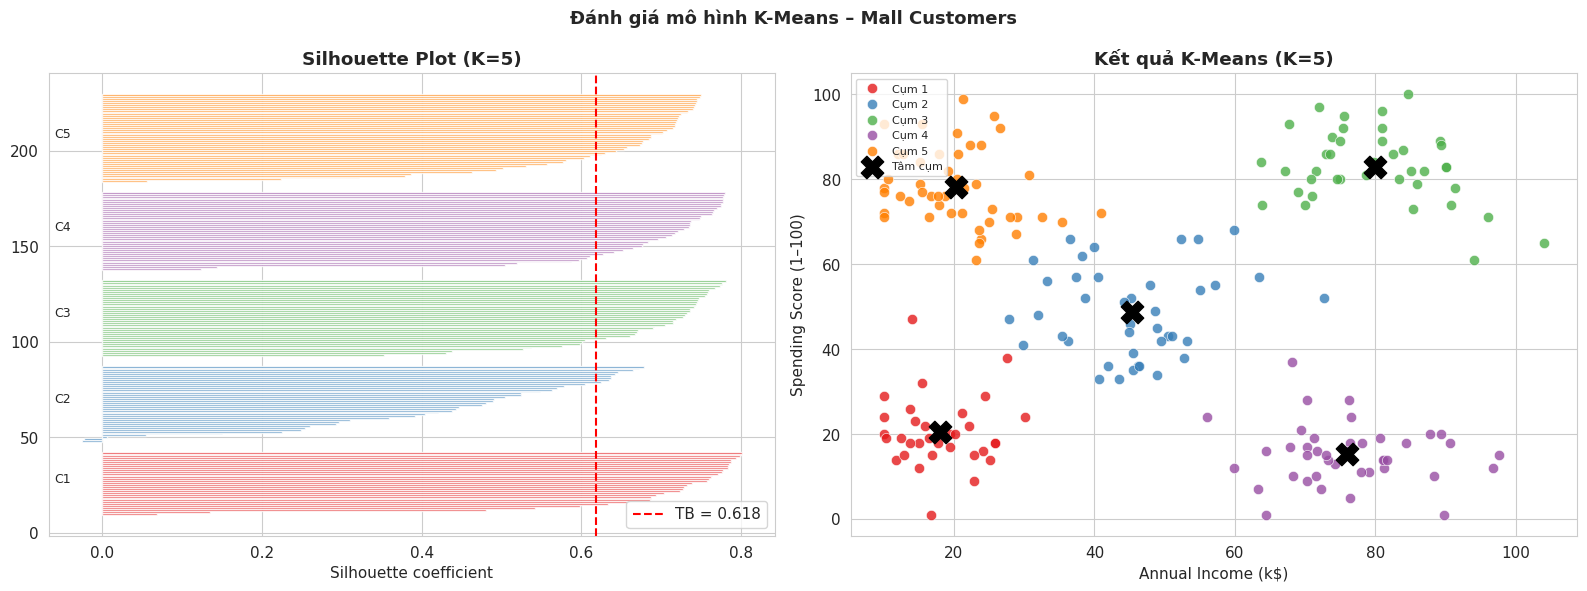

In [ ]:
COLORS = ['#E41A1C','#377EB8','#4DAF4A','#984EA3','#FF7F00','#A65628','#F781BF']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Silhouette Plot ---
y_lo = 10
for k in range(K_FINAL):
    vals_k = np.sort(sil_vals[labels_km == k])
    y_hi = y_lo + len(vals_k)
    axes[0].barh(range(y_lo, y_hi), vals_k, height=1.0, color=COLORS[k], alpha=0.85)
    axes[0].text(-0.06, (y_lo + y_hi) / 2, f'C{k+1}', fontsize=9)
    y_lo = y_hi + 5
axes[0].axvline(sil_avg, color='red', linestyle='--', label=f'TB = {sil_avg:.3f}')
axes[0].set_xlabel('Silhouette coefficient')
axes[0].set_title(f'Silhouette Plot (K={K_FINAL})', fontweight='bold')
axes[0].legend()

# --- Scatter Plot ---
for k in range(K_FINAL):
    mask = labels_km == k
    axes[1].scatter(X_raw[mask, 0], X_raw[mask, 1],
                   c=COLORS[k], s=55, alpha=0.8,
                   edgecolors='white', linewidths=0.5, label=f'Cụm {k+1}')

centers_orig = scaler.inverse_transform(km_final.cluster_centers_)
axes[1].scatter(centers_orig[:,0], centers_orig[:,1],
                c='black', marker='X', s=260, zorder=5, label='Tâm cụm')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1–100)')
axes[1].set_title(f'Kết quả K-Means (K={K_FINAL})', fontweight='bold')
axes[1].legend(loc='upper left', fontsize=8)

plt.suptitle('Đánh giá mô hình K-Means – Mall Customers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Phân tích phân khúc khách hàng

In [ ]:
df['Cluster'] = labels_km

stats = df.groupby('Cluster').agg(
    So_luong=('Age', 'count'),
    Tuoi_TB=('Age', 'mean'),
    Thu_nhap_TB=('Annual_Income_k', 'mean'),
    Score_TB=('Spending_Score', 'mean')
).round(1)
stats['Ti_le_%'] = (stats['So_luong'] / len(df) * 100).round(1)

print('Đặc điểm từng phân khúc:')
print(stats.to_string())

Đặc điểm từng phân khúc:
         So_luong  Tuoi_TB  Thu_nhap_TB  Score_TB  Ti_le_%
Cluster                                                   
0              33     49.4         18.0      20.5     16.5
1              40     38.4         45.3      48.6     20.0
2              40     27.9         79.9      83.0     20.0
3              41     45.9         76.0      15.3     20.5
4              46     26.9         20.3      78.1     23.0


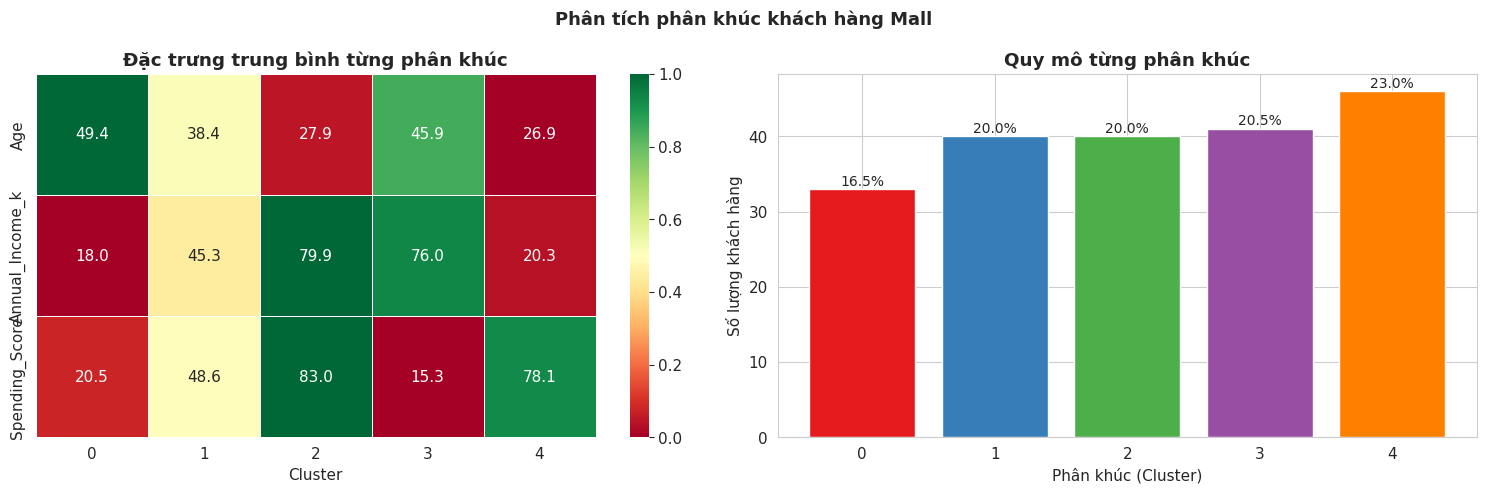

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap đặc trưng cụm
heat_data = df.groupby('Cluster')[['Age','Annual_Income_k','Spending_Score']].mean()
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())
sns.heatmap(heat_norm.T, annot=heat_data.T.round(1), fmt='.1f',
            cmap='RdYlGn', ax=axes[0], linewidths=0.5)
axes[0].set_title('Đặc trưng trung bình từng phân khúc', fontweight='bold')

# Bar chart số lượng
bars = axes[1].bar(stats.index, stats['So_luong'],
                   color=[COLORS[k] for k in stats.index], edgecolor='white')
for bar, (idx, row) in zip(bars, stats.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{row["Ti_le_%"]}%', ha='center', fontsize=10)
axes[1].set_xlabel('Phân khúc (Cluster)')
axes[1].set_ylabel('Số lượng khách hàng')
axes[1].set_title('Quy mô từng phân khúc', fontweight='bold')

plt.suptitle('Phân tích phân khúc khách hàng Mall', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Hierarchical Clustering (so sánh)

Hierarchical Clustering xây dựng cây phân cấp (dendrogram). Không cần biết trước K.

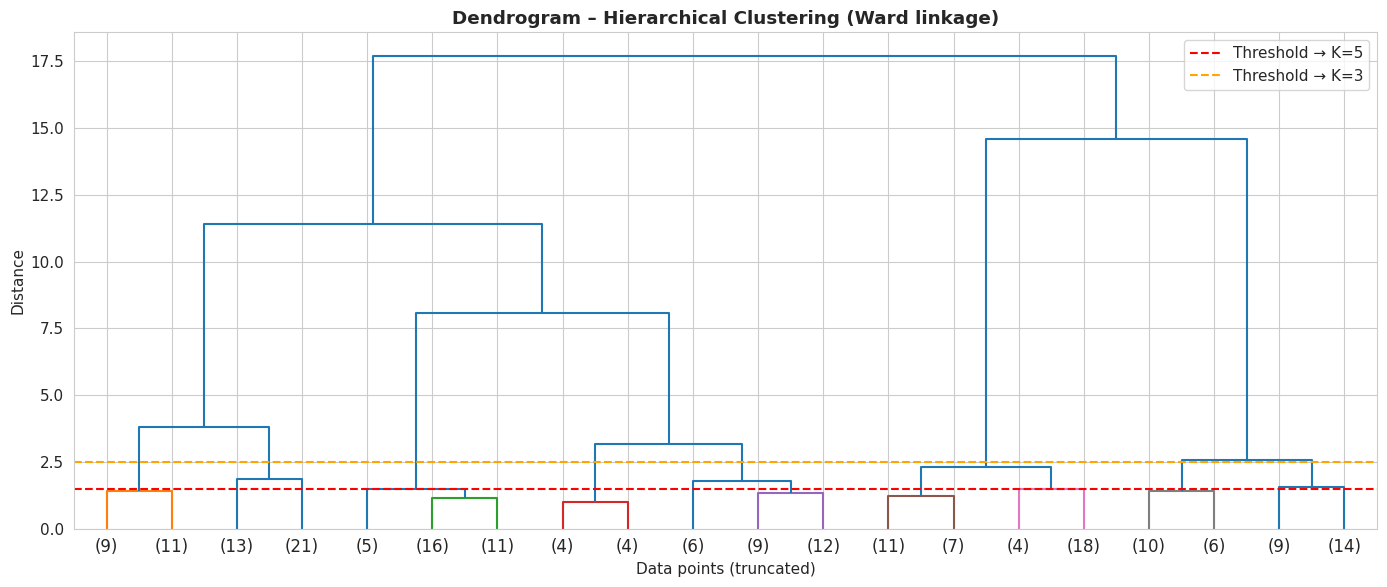

In [ ]:
# Vẽ Dendrogram
Z = linkage(X, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=20,
           color_threshold=1.5, ax=ax)
ax.axhline(y=1.5, color='red', linestyle='--', label='Threshold → K=5')
ax.axhline(y=2.5, color='orange', linestyle='--', label='Threshold → K=3')
ax.set_title('Dendrogram – Hierarchical Clustering (Ward linkage)', fontweight='bold')
ax.set_xlabel('Data points (truncated)')
ax.set_ylabel('Distance')
ax.legend()
plt.tight_layout()
plt.show()

Hierarchical (Ward, K=5): Silhouette = 0.5973
K-means (K=5):            Silhouette = 0.6184


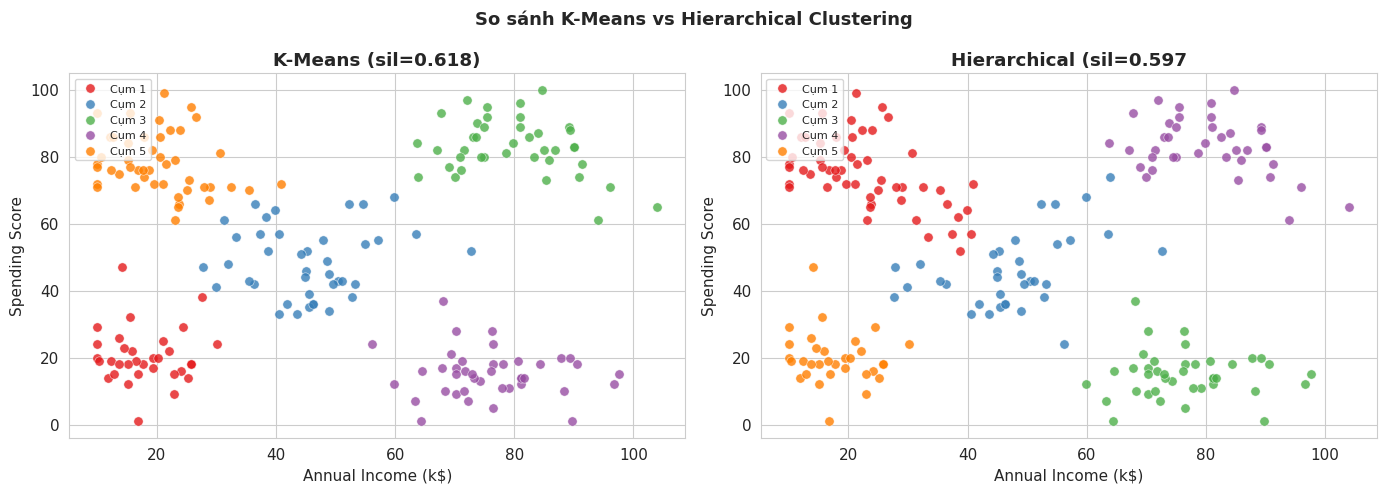

In [ ]:
# Fit Hierarchical với K=5 (cùng K với K-means)
hier = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward')
labels_hier = hier.fit_predict(X)

sil_hier = silhouette_score(X, labels_hier)
print(f'Hierarchical (Ward, K={K_FINAL}): Silhouette = {sil_hier:.4f}')
print(f'K-means (K={K_FINAL}):            Silhouette = {sil_avg:.4f}')

# So sánh scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for k in range(K_FINAL):
    for ax, lbl, title in [(axes[0], labels_km, f'K-Means (sil={sil_avg:.3f})'),
                           (axes[1], labels_hier, f'Hierarchical (sil={sil_hier:.3f}')]:
        mask = lbl == k
        ax.scatter(X_raw[mask,0], X_raw[mask,1],
                   c=COLORS[k], s=45, alpha=0.8,
                   edgecolors='white', linewidths=0.4,
                   label=f'Cụm {k+1}')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Annual Income (k$)')
        ax.set_ylabel('Spending Score')

for ax in axes:
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle('So sánh K-Means vs Hierarchical Clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Bài tập tự luyện

1. Thêm feature `Age` vào phân cụm (3 features: Age, Annual_Income_k, Spending_Score). So sánh Silhouette Score với 2 features.
2. Thử `init='random'` thay vì `'k-means++'`. Chạy 5 lần và quan sát sự khác biệt trong SSE.
3. Thực hiện Hierarchical Clustering với 4 linkage khác nhau (single, complete, average, ward). Vẽ dendrogram và so sánh.
4. Viết hàm `recommend_strategy(cluster_stats)` trả về chiến lược marketing tự động cho từng phân khúc.
5. *(Nâng cao)* Tìm dataset Mall Customers thực tế trên Kaggle và áp dụng lại toàn bộ pipeline này.

---
**Nộp bài:** File notebook đã chạy đầy đủ output với nhận xét và kết luận.